# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012414"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012414
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,16.84
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现金额,平均满意度
0,0-6月,2150,697,0.32,2.50,159.57,3.11
1,7-12月,1584,156,0.10,2.75,163.31,2.99
2,13-24月,1467,95,0.06,3.70,204.92,3.09
3,24月以上,429,0,0.00,3.55,222.34,3.05


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-6月,1,659,375,0.57,2.65,可观察
1,0-6月,0,1491,322,0.22,2.43,可观察
2,7-12月,1,406,81,0.20,2.67,可观察
3,13-24月,1,414,52,0.13,3.35,可观察
4,7-12月,0,1178,75,0.06,2.78,可观察


检查点1A通过：输入文件有效


In [4]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期阶段的用户流失率分别是多少？哪个阶段流失风险最高？",
    "behavior_scatter": "用户订单数与返现金额之间存在什么关系？高消费用户有什么特征？",
    "ordered_line": "随着用户使用时长增加，用户的平均订单数和满意度呈现怎样的变化趋势？",
    "composition_chart": "平台用户的生命周期分布结构是怎样的？各阶段用户占比如何？"
}

chart_reasons = {
    "category_bar": "柱状图适合对比不同分类（生命周期阶段）之间的流失率差异，能够直观展示各阶段的流失风险高低。",
    "behavior_scatter": "散点图适合展示两个连续数值变量（订单数与返现金额）的相关关系，便于发现用户行为分布规律和异常点。",
    "ordered_line": "折线图适用于有序阶段（生命周期从新到老）的趋势展示，能够清晰呈现指标随使用时长的变化走势。",
    "composition_chart": "饼图适合展示各生命周期阶段用户数的整体构成比例，直观反映平台用户结构分布。"
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [5]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-6月,2150,0.32
1,13-24月,1467,0.06
2,24月以上,429,0.00
3,7-12月,1584,0.10


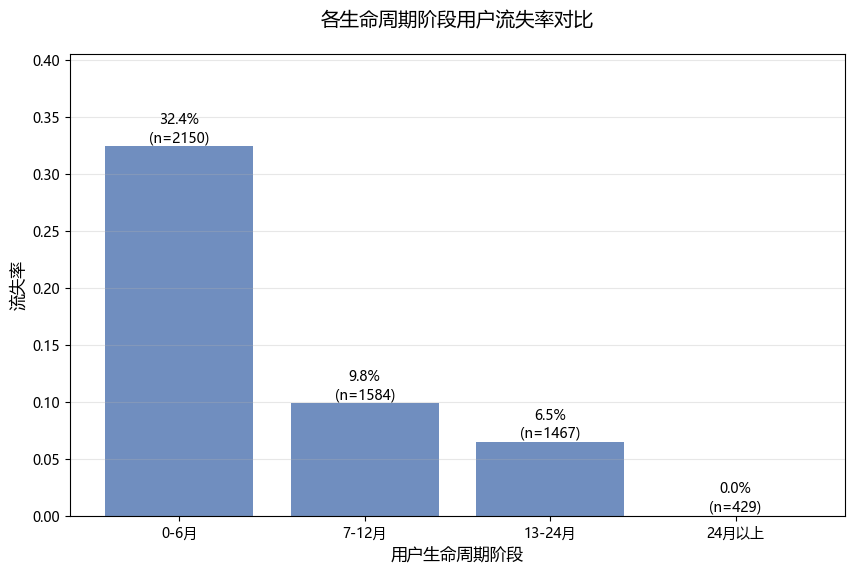

已输出： output\day06_visualization\01_category_bar.png


In [6]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 按生命周期顺序排序
tenure_order = ["0-6月", "7-12月", "13-24月", "24月以上"]
plot_data = category_summary.set_index("TenureGroup").reindex(tenure_order).reset_index()

# 绘制柱状图
bars = ax_bar.bar(plot_data["TenureGroup"], plot_data["流失率"], color="#4C72B0", alpha=0.8)

# 在柱子上标注流失率和用户数（样本量）
for i, bar in enumerate(bars):
    height = bar.get_height()
    user_count = plot_data["用户数"].iloc[i]
    ax_bar.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}\n(n={user_count})',
                ha='center', va='bottom', fontsize=10)

# 图表设置
ax_bar.set_title("各生命周期阶段用户流失率对比", fontsize=14, pad=20)
ax_bar.set_xlabel("用户生命周期阶段", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.set_ylim(0, max(plot_data["流失率"]) * 1.25)
ax_bar.grid(axis='y', alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：请填写。
- 证据：请填写具体数值、差异和样本量。
- 边界：请填写该图不能证明什么。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


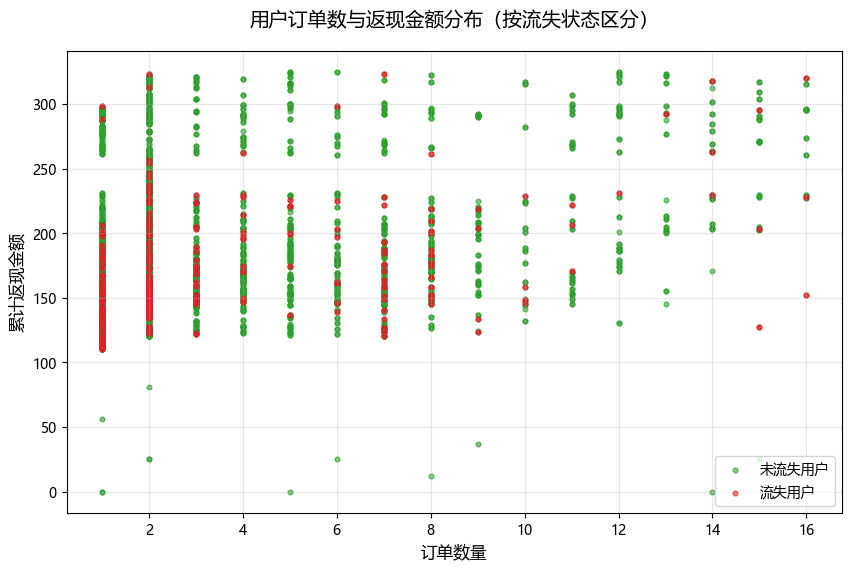

已输出： output\day06_visualization\02_behavior_scatter.png


In [7]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按流失状态分组绘图，设置透明度alpha=0.6
# 未流失用户 Churn=0
df[df["Churn"] == 0].plot.scatter(
    x=x_field, y=y_field, ax=ax_scatter,
    color="#2ca02c", alpha=0.6, label="未流失用户", s=12
)
# 流失用户 Churn=1
df[df["Churn"] == 1].plot.scatter(
    x=x_field, y=y_field, ax=ax_scatter,
    color="#d62728", alpha=0.6, label="流失用户", s=12
)

# 图表美化
ax_scatter.set_title("用户订单数与返现金额分布（按流失状态区分）", fontsize=14, pad=18)
ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("累计返现金额", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

# 保存图片
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：请填写。
- 证据：请填写两个变量的关系、聚集或异常。
- 边界：相关关系不等于因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [8]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        平均流失率=("Churn", "mean")
    )
    .reset_index()
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均流失率
0,0-6月,2150,0.32
1,13-24月,1467,0.06
2,24月以上,429,0.00
3,7-12月,1584,0.10


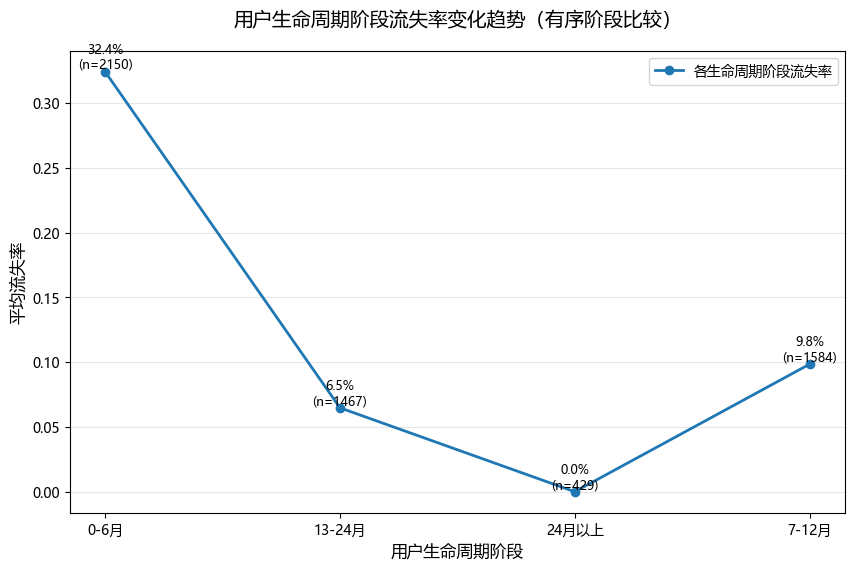

已输出： output\day06_visualization\03_ordered_line.png


In [9]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["平均流失率"],
    marker="o", linewidth=2, color="#1f77b4", label="各生命周期阶段流失率"
)
for idx, row in ordered_summary.iterrows():
    rate = row["平均流失率"]
    user_cnt = row["用户数"]
    ax_line.text(
        x=idx, y=rate,
        s=f"{rate:.1%}\n(n={user_cnt})",
        ha="center", va="bottom", fontsize=9
    )
ax_line.set_title("用户生命周期阶段流失率变化趋势（有序阶段比较）", fontsize=14, pad=18)
ax_line.set_xlabel("用户生命周期阶段", fontsize=12)
ax_line.set_ylabel("平均流失率", fontsize=12)
ax_line.grid(axis="y", alpha=0.3)
ax_line.legend()
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：请填写。
- 证据：请填写具体数值和样本量。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [11]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0-6月,2150,0.38
1,13-24月,1467,0.26
2,24月以上,429,0.08
3,7-12月,1584,0.28


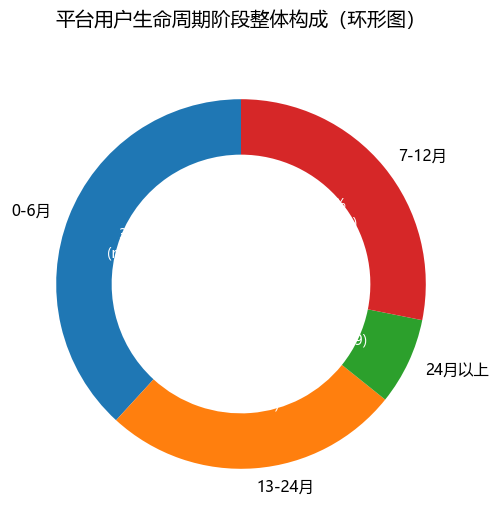

已输出： output\day06_visualization\04_composition_chart.png


In [13]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
total_user = sizes.sum()  # 总用户数，提前算好

# 绘制环形饼图，修正autopct逻辑
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%\n(n={int(p / 100 * total_user)})",
    wedgeprops={"width": 0.3},
    startangle=90
)

# 美化文字
for txt in texts:
    txt.set_fontsize(11)
for autotxt in autotexts:
    autotxt.set_color("white")
    autotxt.set_fontsize(10)

ax_composition.set_title("平台用户生命周期阶段整体构成（环形图）", fontsize=14, pad=20)
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：请填写。
- 证据：请填写主要类别占比。
- 边界：请说明该图适合或不适合进行哪些比较。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [14]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


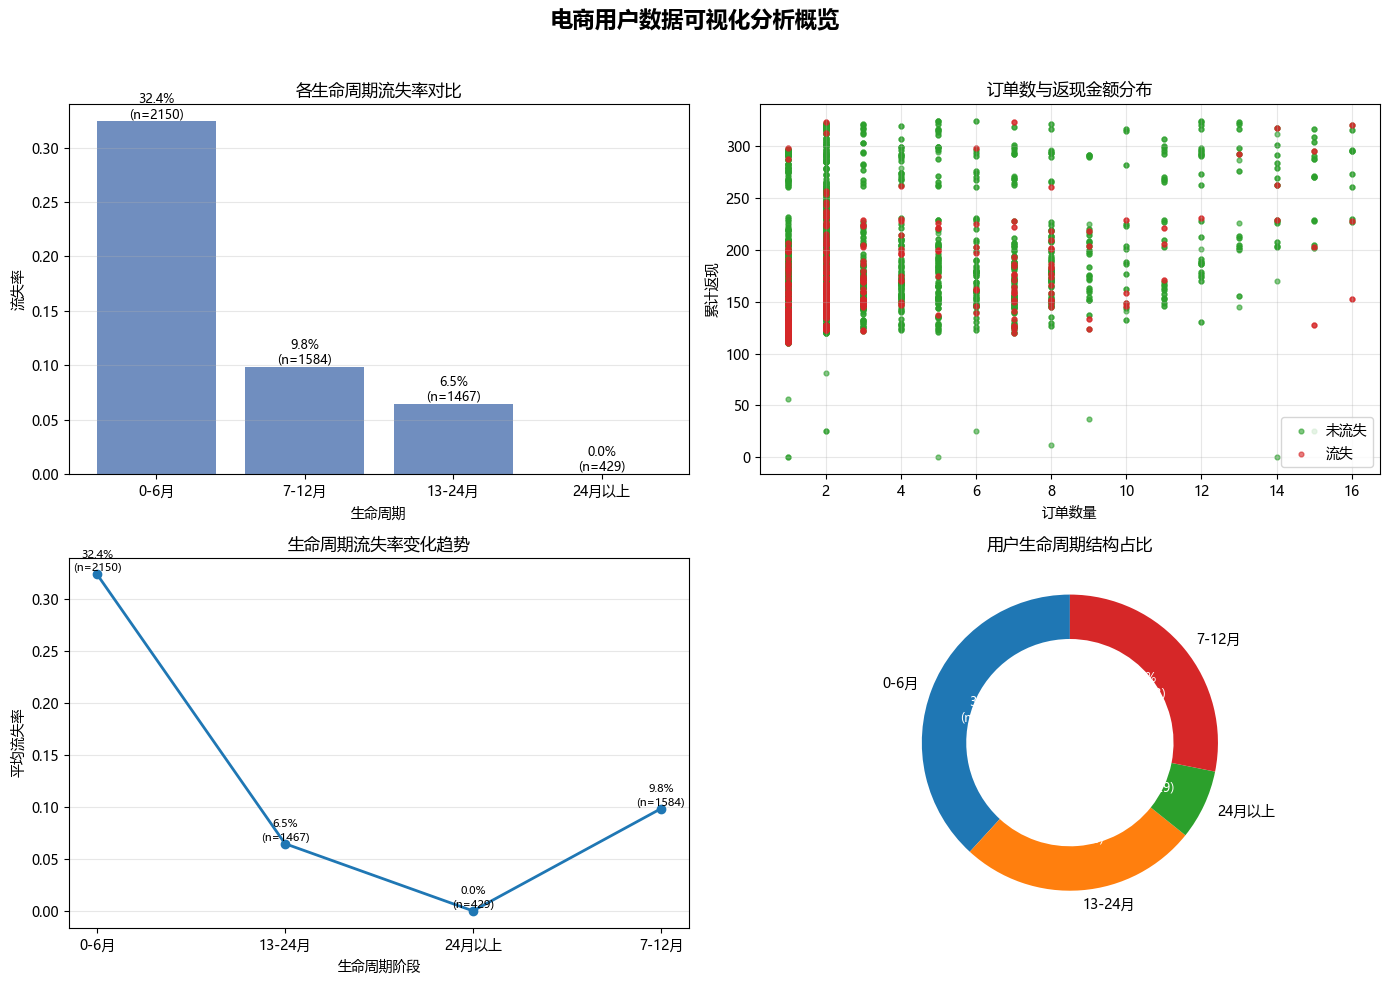

已输出： output\day06_visualization\day06_visualization_summary.png


In [15]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
ax00, ax01 = axes[0]
ax10, ax11 = axes[1]

tenure_order = ["0-6月", "7-12月", "13-24月", "24月以上"]
plot_bar = category_summary.set_index("TenureGroup").reindex(tenure_order).reset_index()
bars = ax00.bar(plot_bar["TenureGroup"], plot_bar["流失率"], color="#4C72B0", alpha=0.8)
for i, bar in enumerate(bars):
    h = bar.get_height()
    cnt = plot_bar["用户数"].iloc[i]
    ax00.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1%}\n(n={cnt})", ha="center", va="bottom", fontsize=9)
ax00.set_title("各生命周期流失率对比", fontsize=12)
ax00.set_xlabel("生命周期")
ax00.set_ylabel("流失率")
ax00.grid(axis="y", alpha=0.3)
df[df["Churn"]==0].plot.scatter(x=x_field, y=y_field, ax=ax01, color="#2ca02c", alpha=0.6, s=12, label="未流失")
df[df["Churn"]==1].plot.scatter(x=x_field, y=y_field, ax=ax01, color="#d62728", alpha=0.6, s=12, label="流失")
ax01.set_title("订单数与返现金额分布", fontsize=12)
ax01.set_xlabel("订单数量")
ax01.set_ylabel("累计返现")
ax01.legend()
ax01.grid(alpha=0.3)

ax10.plot(ordered_summary[ordered_field], ordered_summary["平均流失率"], marker="o", linewidth=2, color="#1f77b4")
for idx, row in ordered_summary.iterrows():
    r = row["平均流失率"]
    c = row["用户数"]
    ax10.text(idx, r, f"{r:.1%}\n(n={c})", ha="center", va="bottom", fontsize=8)
ax10.set_title("生命周期流失率变化趋势", fontsize=12)
ax10.set_xlabel("生命周期阶段")
ax10.set_ylabel("平均流失率")
ax10.grid(axis="y", alpha=0.3)

total_user = composition_summary["用户数"].sum()
wedges, texts, autotexts = ax11.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct=lambda p: f"{p:.1f}%\n(n={int(p/100*total_user)})",
    wedgeprops={"width":0.3}, startangle=90
)
for t in texts:
    t.set_fontsize(10)
for autot in autotexts:
    autot.set_color("white")
    autot.set_fontsize(9)
ax11.set_title("用户生命周期结构占比", fontsize=12)
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：请填写，并给出证据。
2. 综合发现2：请填写，并给出证据。
3. 综合发现3：请填写，并给出证据。
4. 数据或方法局限：请填写。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [16]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同生命周期阶段用户流失率分别是多少，哪个阶段流失风险最高？", "chart_type": "bar", "key_finding": "0-6月新用户流失率32.4%，显著高于其余阶段；随生命周期拉长流失率持续下降，24个月以上用户无流失", "limitation": "仅展示分组均值，无法体现组内个体差异；横截面静态数据，无法判断流失发生时序先后"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数量与累计返现金额存在何种关联？", "chart_type": "scatter", "key_finding": "流失用户集中在低订单、低返现区间；高订单、高返现区间几乎全部为留存用户", "limitation": "仅能证明变量相关，无法判定因果；高密度点重叠遮挡，局部细节观察受限"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "用户生命周期由短至长，平均流失率呈现怎样的连续变化趋势？", "chart_type": "line", "key_finding": "流失率随使用时长单调递减，0-6月至13-24月衰减幅度最大，24个月以上流失率归零，7-12月小幅回升至9.8%", "limitation": "仅单一流失率指标，未结合满意度、投诉等辅助行为；无月度时序数据，无法追踪单用户长期变化"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "平台整体用户生命周期结构分布如何，各阶段用户体量占比多少？", "chart_type": "pie_or_bar", "key_finding": "0-6月新用户体量最大（2150人），占平台近四成；24个月以上长期用户基数最小，存量老用户稀缺", "limitation": "仅静态存量占比，缺少用户新增、流失流转时序数据，无法分析用户生命周期流转链路；仅用户数量维度，未加权消费价值"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "生命周期与流失高度相关，低活跃度新用户是平台流失核心短板，高消费用户留存稳定", "limitation": "多图合并后数值标注偏小，不适合精细化单指标深度分析；缺少双维交叉细分视图，仅展示四类基础图表"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段用户流失率分别是多少，哪个阶段流失风险最高？,bar,0-6月新用户流失率32.4%，显著高于其余阶段；随生命周期拉长流失率持续下降，24个月以上...,仅展示分组均值，无法体现组内个体差异；横截面静态数据，无法判断流失发生时序先后
1,02,02_behavior_scatter.png,订单数量与累计返现金额存在何种关联？,scatter,流失用户集中在低订单、低返现区间；高订单、高返现区间几乎全部为留存用户,仅能证明变量相关，无法判定因果；高密度点重叠遮挡，局部细节观察受限
2,03,03_ordered_line.png,用户生命周期由短至长，平均流失率呈现怎样的连续变化趋势？,line,流失率随使用时长单调递减，0-6月至13-24月衰减幅度最大，24个月以上流失率归零，7-1...,仅单一流失率指标，未结合满意度、投诉等辅助行为；无月度时序数据，无法追踪单用户长期变化
3,04,04_composition_chart.png,平台整体用户生命周期结构分布如何，各阶段用户体量占比多少？,pie_or_bar,0-6月新用户体量最大（2150人），占平台近四成；24个月以上长期用户基数最小，存量老用户稀缺,仅静态存量占比，缺少用户新增、流失流转时序数据，无法分析用户生命周期流转链路；仅用户数量维度...
4,05,day06_visualization_summary.png,整体概览,dashboard,生命周期与流失高度相关，低活跃度新用户是平台流失核心短板，高消费用户留存稳定,多图合并后数值标注偏小，不适合精细化单指标深度分析；缺少双维交叉细分视图，仅展示四类基础图表


In [17]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
